In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import pandas as pd
import harmonica as hm
from pyrocko import cake
import obspy

# NEWBERRY VOLCANO - Gravity/Magnetic Analysis
#### Rohan Batten

---
# 1. Initialialization

---
#### 1.1 - Basic Information

Newberry Volcano, Oregon

From given README file:

"GRAVITY: 
For your study, assume that the standard magnitude of density contrast for a body of magma compared to the surrounding rock is between approximately 180 and 400 kg/m3 (in magnitude!). You can also assume for the purposes of your study that the standard magnitude of density contrast for hydrothermal features has a magnitude between 50 and 180 (ish) kg/m3. Real life is far more complicated, but these are the numbers you have to go on. The Newberry gravity and magnetic data has a North-South map orientation, with the northernmost part at x=0. The most relevant lab work is from Lab 6: Gravity.

MAGNETIC:
For the purposes of your magnetic study, magma will have a small, and generally negative magnetic anomaly (anything near or above the Curie point will have a very low magnetic susceptibility). Hydrothermal features will have a larger and generally positive magnetic anomaly (due to the presence of metals and salts). Intrusive features (e.g. cooled intrusive structures like batholiths, etc.) will have a higher magnetic susceptibility, and generally positive magnetic anomaly. For intuition: hydrothermal features are on the order of less than 1 km wide generally (but Yellowstone is weird), magma chambers can be on the order of 1-10 km, and cooled intrusions will be similar to or larger than the magma chambers (generally). Hydrothermal systems can be deep and narrow, as they are essentially plumbing surface (meteoric) water deep enough to make it so hot that it returns to the surface (generally much hotter than boiling). The most relevant lab work is from Lab 8: Magnetics."



OVERALL Mission

As a geophysicist employed by the Generic Geothermal Resource Company, you have been selected to perform a geophysical study of Newberry Volcano, a shield-shaped stratovolcano in the Cascade Range in Oregon. The current caldera formed about 75,000 years ago during a major explosive eruption, and the most recent eruption was approximately 1,300 years ago. Hot springs in the caldera are active.

While Newberry Volcano is quiet now, it has a very high capacity to cause damage– any eruption of a similar style to the previous eruptions could bury most of central Oregon. However, you are mostly interested in the area for the geothermal energy resources. Your job is NOT to recommend a specific site to drill for geothermal resources. Rather, your job is to (1) image the subsurface, (2) investigate general areas where magma might be more shallow (of interest due to the altered geothermal gradient), and (3) look for areas with hydrothermal activity due to easier access to geothermal resources. Make your judgement on the general areas where geothermal energy resources would be more accessible, explicitly state why you believe your ideas to be correct, and explain your reasoning.

For the upper layer of your seismic imaging: what are the most likely rock types for the upper layer? You don’t need to cite specific formations, but state a generic rock or deposit type (pyroclastic flow deposits, tuff, rhyolite, granite, basalt, glacial till, etc.). Combine your judgment on this (which should primarily be based on the measured velocities) with information from a geologic map. Again, you do not need to cite any specific formations or map units, just a generic rock type.

Geothermal energy resources are areas where Earth’s internal heat is available closer to the surface than average. These resources come in the form of hot springs (which are generally used directly for heating) and hot aquifers (which allow for actual generating of electricity).

---
#### 1.2 - Data Import and Assignment

In [93]:
# import data files for reflection (rl) and refraction (rc)
df_grav = pd.read_csv('newberry_gravity.csv', names=["x_grav", "anom_grav"], skiprows=1)
df_mag = pd.read_csv('newberry_magnetics.csv', names=["x_mag", "anom_mag"], skiprows=1)  #skiprows so it doesn't include the header name

# assign each column of times to a variable
x_grav = df_grav['x_grav']
anom_grav = df_grav['anom_grav']  # gravity

x_mag = df_mag['x_mag']
anom_mag = df_mag['anom_mag']  # refraction

# variables from seismic analysis
# velocities [m/s]
V_1 = 800.0320760205128
V_2 = 2510.19857794
V_3 = 4051.95463568
V_4 = 5884.78656288
V_5 = 6015.38656103
# densities [kg/m^3] (from estimated rock types, may not be extremely accurate) (see report for sources)
p_1 = 300
p_2 = 1500
p_3 = 2400
p_4 = 2700
p_5 = 2900

---
# 2. Plotting Data

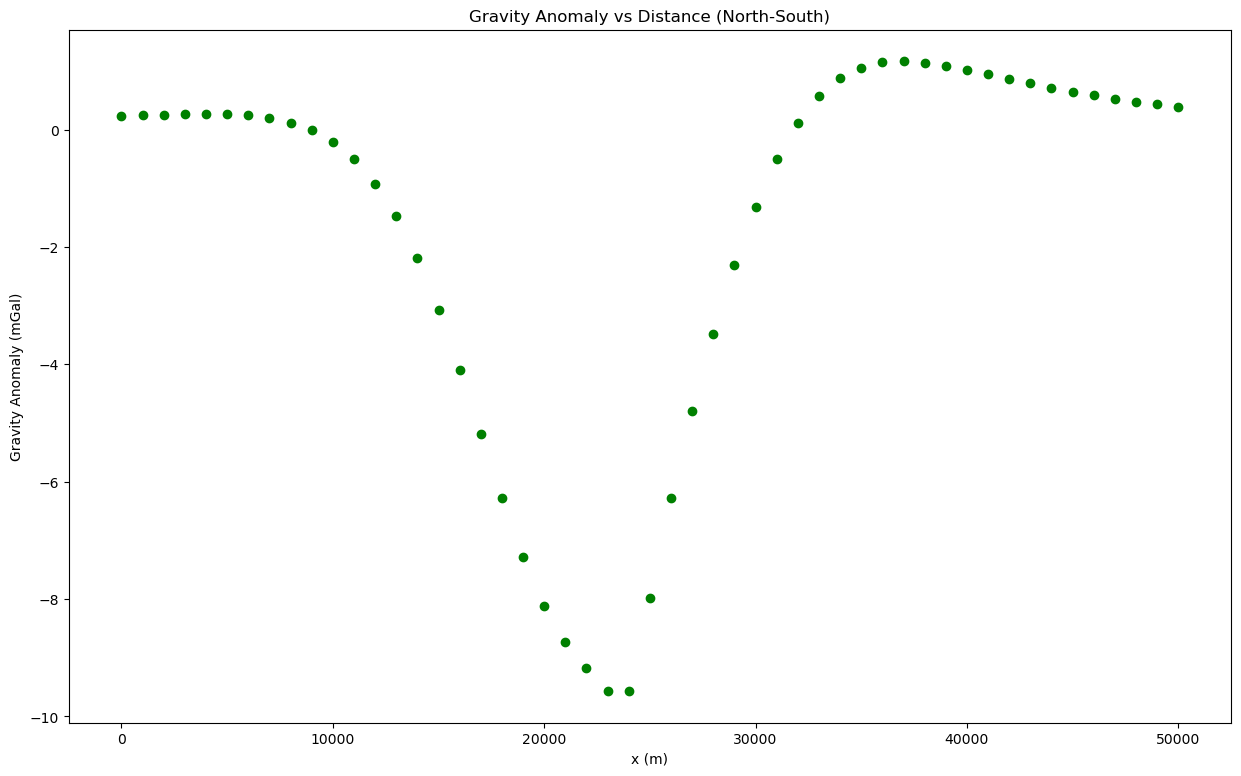

In [3]:
plt.figure(figsize=(15,9))

# gravity
plt.scatter(x_grav, anom_grav, color = 'green')
plt.xlabel('x (m)')
plt.ylabel('Gravity Anomaly (mGal)')
plt.title('Gravity Anomaly vs Distance (North-South)');

plt.savefig('gravity_data_graph.png', bbox_inches='tight')

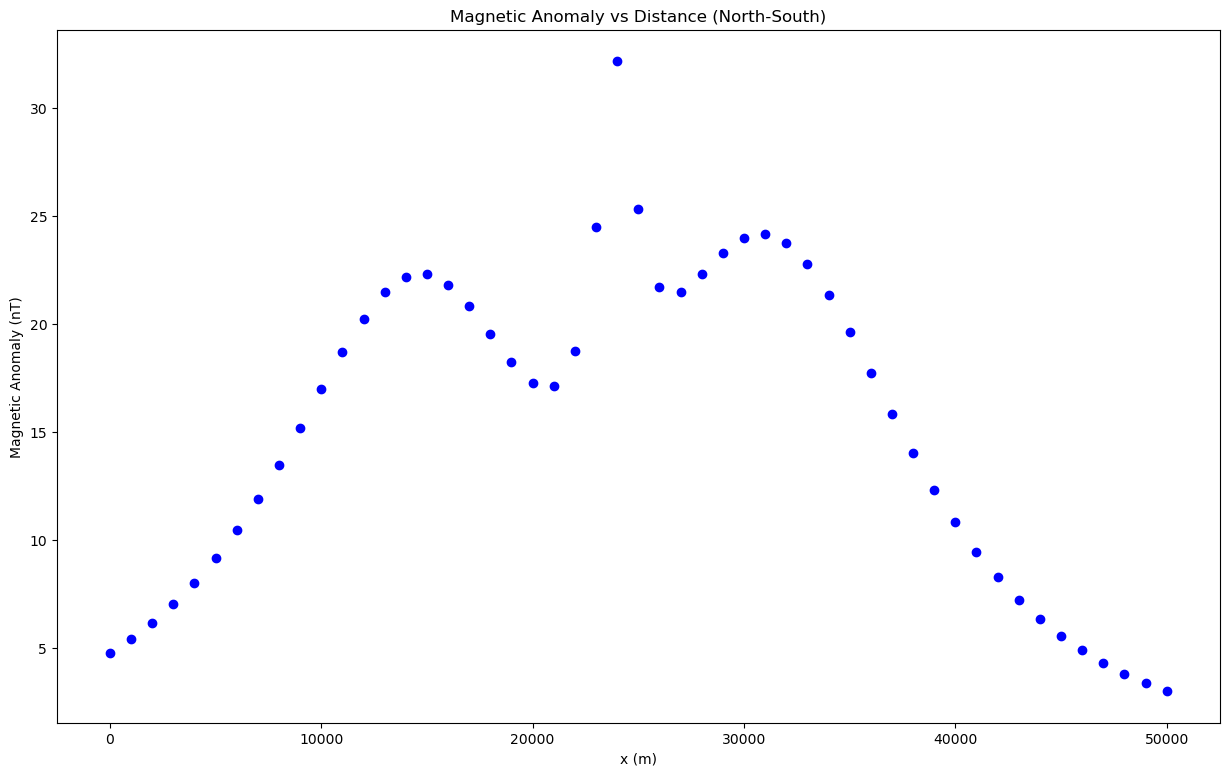

In [4]:
plt.figure(figsize=(15,9))

# magnetics
plt.scatter(x_mag, anom_mag, color = 'blue')
plt.xlabel('x (m)')
plt.ylabel('Magnetic Anomaly (nT)')
plt.title('Magnetic Anomaly vs Distance (North-South)');

plt.savefig('magnetic_data_graph.png', bbox_inches='tight')

---
# 3 - Gravity Analysis


---
#### 3.1 - Harmonica Modeling

This gravity graph shows a negative anomaly near the center, pointing to a low-density zone. This would fit with something like a magma chamber.

We can also note a positive peak on the south side of the negative dip. This has me suspect there are two bodies, where a smaller positive anomaly is given by a hydrothermal feature.

We are given a density contrast between magma and the surrounding rock of somwhere within 180 to 400 $kg/m^3$. We are also given a density contrast between hydrothermal bodies and the surrounding rock of 50 to 180 $kg/m^3$. 

I assumed one large magma chamber, a thinner magma chamber in the middle, and a couple of positive anomaly bodies on the sides. Four bodies in total.

The x point closest to the halfway anomaly is index 18, entry 17. x = 17000 m, anomaly = -5.184795240562285. This value is on the left side of the parabola (more north) as that side is less altered from a regular curve. From this value, and the peak value at x = 23000 m, we determine the $x_{1/2}$ value.

From there, we can use the equation

\begin{equation}
\tag{3.1.1}
z = x_{1/2}
\end{equation}

to get the depth of the negative anomaly body (the large magma chamber). This assumes a slab body.


In [5]:
peak_grav = np.min(anom_grav)  # finding the peak anomaly (lowest point of the anomaly)
grav_half = peak_grav / 2  # calculate what half of the peak anomaly is

# take the x-value of the nearest point to peak_grav and subtract it from grav_half
x_half = 23000 - 17000

z_top = x_half  # this will be the top of the negative anomaly body, in m
print(z_top)

6000


Then, we can use this value to put into a harmonica model. This process is largely guess-and-check.

the minimum gravity anomaly for the model is -9.62697441448951 mGal
the minimum gravity anomaly for the data is -9.570834854816836 mGal
the difference between the model and the data minimum is 0.056139559672674366 mGal


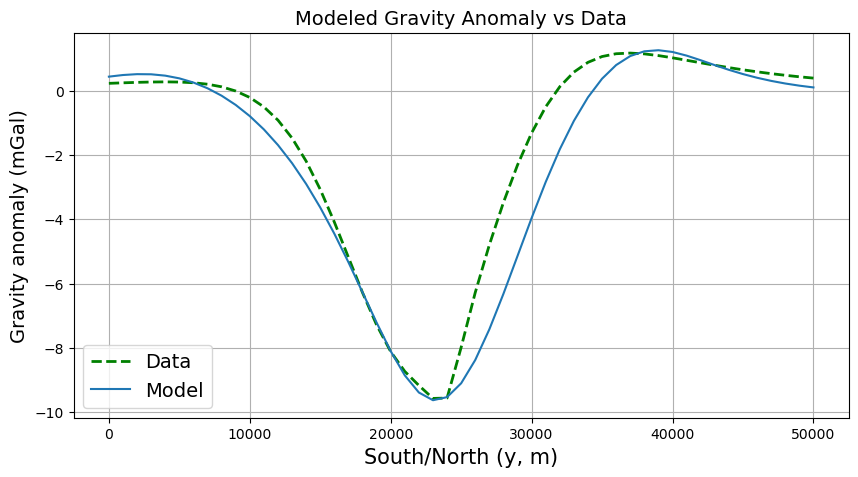

In [6]:
peak_grav = np.min(anom_grav)  # finding the peak anomaly (lowest point of the anomaly)
grav_half = peak_grav / 2  # calculate what half of the peak anomaly is

# the following code is taken from Lab 6 (Courtesy of Emily Wilbur)
# environment values
region      = (0, 50000, 0, 50000)  # (x_min, x_max, y_min, y_max), all in meters
shape       = (51, 51)              # (n_x, n_y) for number of points
height      = 0                     # height where the measurement should be made, in meters -- don't change this
coordinates = vd.grid_coordinates(region, shape=shape, extra_coords=height) 

# block values
blocks = [[20500, 26500, 0, 50000, -13750, -6100],  # (x_min, x_max, y_min, y_max, z_min, z_max) of deep magma block
          [22500, 23500, 0, 50000, -6100, -5000],   # (x_min, x_max, y_min, y_max, z_min, z_max) of shallow magma block
          [0, 20000, 0, 50000, -10000, -6000],      # (x_min, x_max, y_min, y_max, z_min, z_max) of north positive block
          [30000, 40000, 0, 50000, -12000, -5000]]  # (x_min, x_max, y_min, y_max, z_min, z_max) of south positive block
density = [-400,   # density contrast for deep magma block
           -400,   # density contrast for shallow magma block
           60,     # density contrast for north positive block
           100,]   # density contrast for south positive block

hm_result = hm.prism_gravity(coordinates, blocks, density, field='g_z')
print(f"the minimum gravity anomaly for the model is {np.min(hm_result[50,:])} mGal")
print(f"the minimum gravity anomaly for the data is {np.min(anom_grav)} mGal")
diff = np.abs(np.min(hm_result[50,:]) - np.min(anom_grav))
print(f"the difference between the model and the data minimum is {diff} mGal")

# plotting the anomaly model onto the data to fit it
plt.figure(figsize=(10, 5))
plt.plot(x_grav, anom_grav, c='g', linestyle='--', label = 'Data', linewidth = 2)
plt.plot(x_grav, hm_result[50,:], label = 'Model')
plt.xlabel("South/North (y, m)", fontsize=15)
plt.ylabel("Gravity anomaly (mGal)", fontsize=14)
plt.title("Modeled Gravity Anomaly vs Data", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14);
plt.savefig('gravity_model_graph.png', bbox_inches='tight')

From this estimate, we get a close minimum value (only 0.056 mGal). This shows that a central pair of magma bodies and a couple of positive density bodies on the sides can get a somewhat accurate view of the data.

The data is not a perfect fit; this was a lot of trial and error estimates from manipulating three bodies.

The positive bodies are unknowns. Perhaps high-density intrusions of lava that are dense and basaltic may appear where magma has seeped.

---
#### 3.2 - Gravity Summary

From the gravity, there are four bodies estimated to be in the subsurface

|Body:        |Deep Magma Chamber |Shallow Magma Chamber |North Positive Body |South Positive Body |
|-------------|-------------------|---------------------|---------------------|--------------------|
|North (m)    |20500              |22500                |0                    |22500               |
|South (m)    |26500              |23500                |20000                |41000               |
|Width (m)    |6000               |1000                 |20000                |18500               |
|Top (m)      |-6100              |-5000                |-6000                |-5000               |
|Bottom (m)   |-13750             |-6100                |-13000               |-12000              |
|Thickness (m)|7650               |1100                 |7000                 |7000                |


---
# 4. Magnetic Analysis

---
#### 4.1 - Harmonica Modeling

I used NOAA's magnetic field calculator with a latitude of 43.722 degrees N and a longitude of 121.229 degrees W. I got an inclination $I$ of 66.0599 degrees, a declination $D$ of 13.7926 degrees, and a total field $F$ of 50,830.2 nT. From these, we can calculate the magnetization vector for the rocks using the equations (5.3.2 in Lowrie)

\begin{equation}
\tag{4.1.1}
X = \kappa F\cos{(D)}\cos{(I)}
\end{equation}

\begin{equation}
\tag{4.1.2}
Y = \kappa F\cos{(D)}\sin{(I)}
\end{equation}

\begin{equation}
\tag{4.1.3}
Z = \kappa F\sin{(D)}
\end{equation}

in which $\kappa$ is the magnetic susceptibility of the body. I assumed a $\kappa$ of $0.001$ for the positive bodies. This will only apply to bodies other than magma; magma does not have a magnetization, or very little.

In [7]:
F = 50830.2
I = np.deg2rad(66.0599)
D = np.deg2rad(13.7926)
kappa = 0.0000000001

mag_vec_x_nT = kappa * F * np.cos(I) * np.cos(D)  # North
mag_vec_y_nT = kappa * F * np.cos(I) * np.sin(D)  # East
mag_vec_z_nT = kappa * F * np.sin(I)              # Depth

# then convert to A/m for harmonica
mag_vec_x = mag_vec_x_nT / (4 * np.pi * 10**(-7))
mag_vec_y = mag_vec_y_nT / (4 * np.pi * 10**(-7))
mag_vec_z = mag_vec_z_nT / (4 * np.pi * 10**(-7))

$\kappa$ is strangely small to produce usable values. I don't know why this is. It should be around ~0.001.

Then, we plug into the Harmonica model for magnetics. For this, what were previously x coordinates are now y coordinates.

I also found the data fit better with a large block with a small magnetization under the entire area. This fit the edges to where they should be. This is marked as the saturation block.

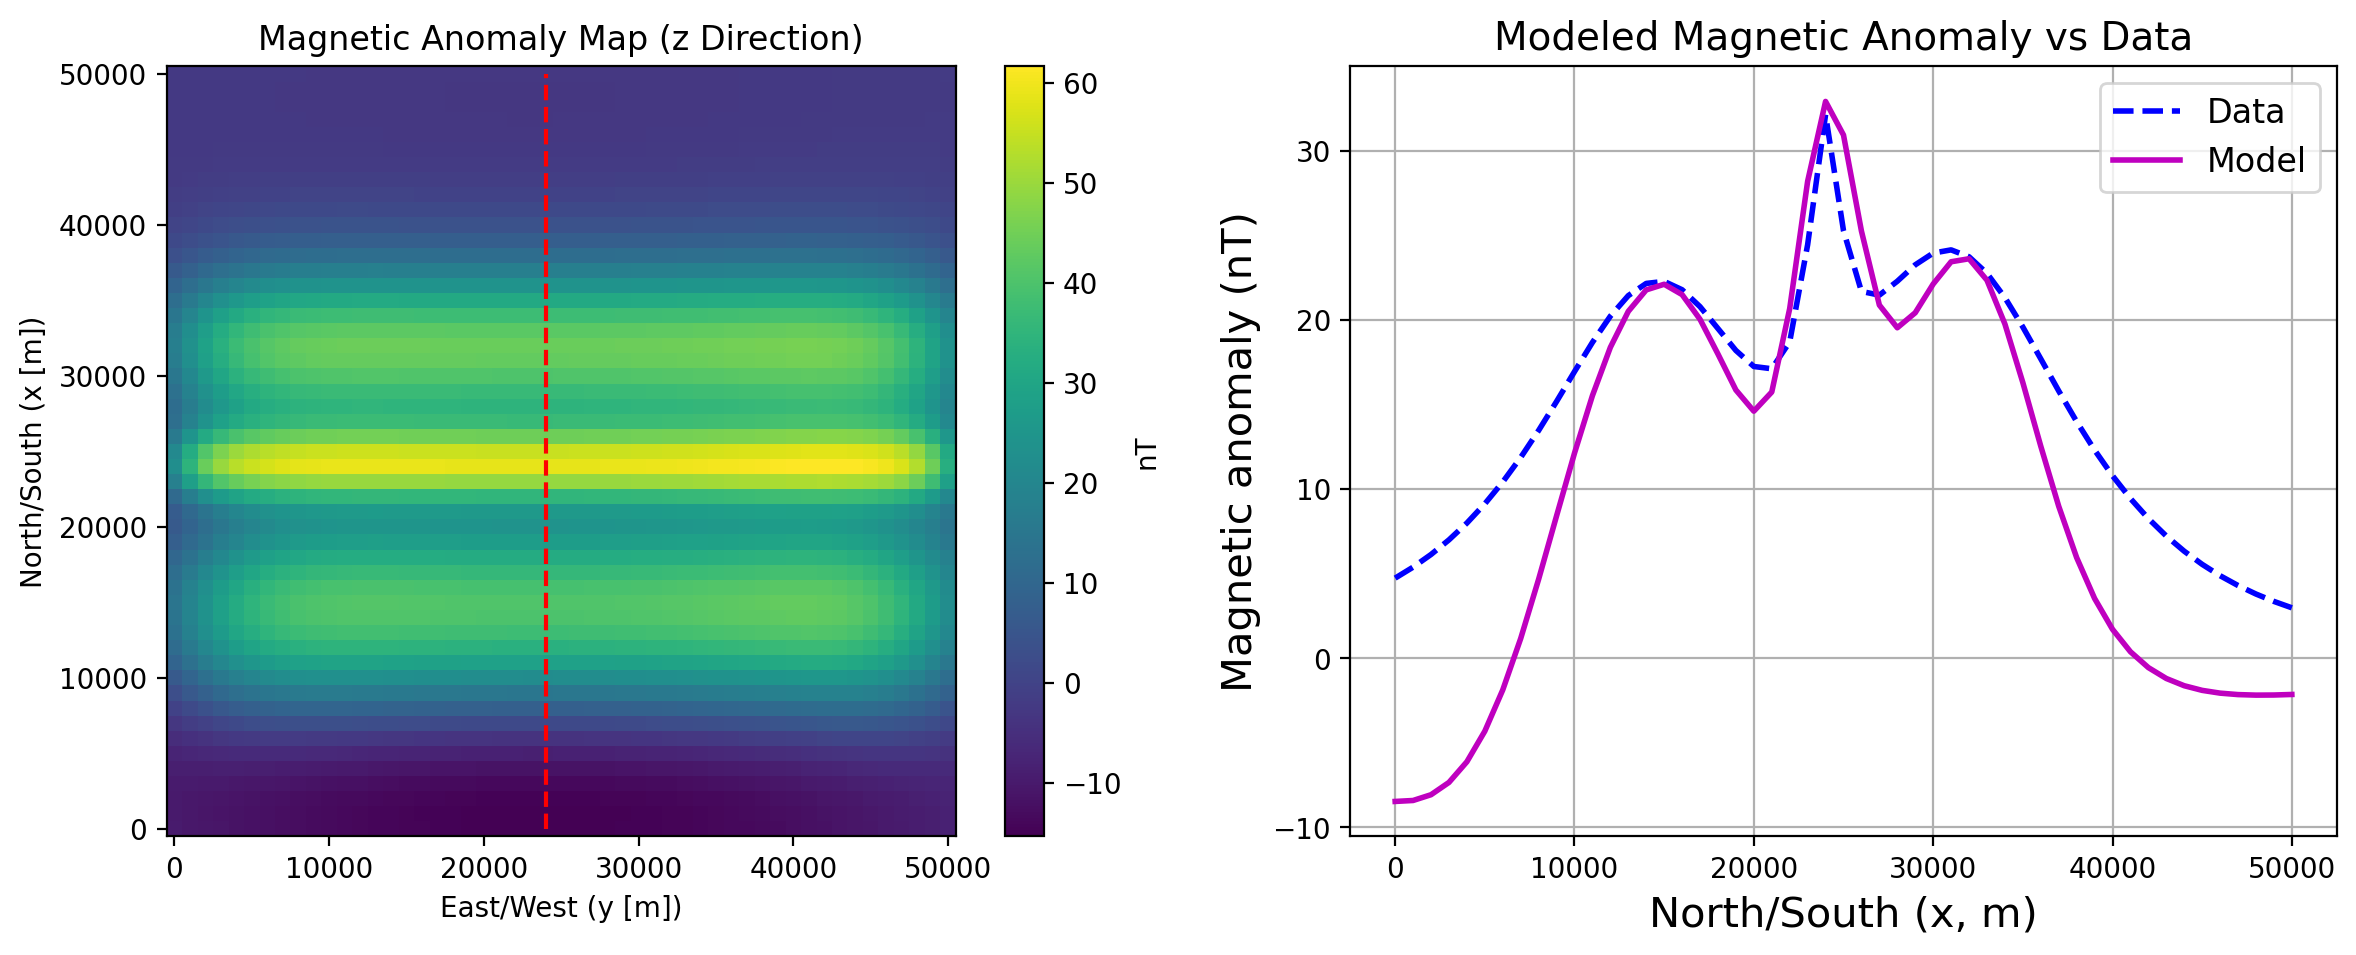

In [103]:
# the following code is taken from Lab 8 (Courtesy of Emily Wilbur)
# environment values
region      = (0, 50000, 0, 50000)  # (x_min, x_max, y_min, y_max), all in meters
shape       = (51, 51)              # (n_x, n_y) for number of points
height      = 0                     # height where the measurement should be made, in meters -- don't change this
coordinates = vd.grid_coordinates(region, shape=shape, extra_coords=height) 

# block values
block = [[0, 50000, 17000, 30000, -6800, -6000],  # (x_min, x_max, y_min, y_max, z_min, z_max) of deep magma block
          [0, 50000, 23000, 24500, -4200, -3600],   # (x_min, x_max, y_min, y_max, z_min, z_max) of shallow magma block (positive?)
          [0, 50000, 19000, 21000, -5200, -5100],   # (x_min, x_max, y_min, y_max, z_min, z_max) of NEGATIVE CORRECT
          [0, 50000, 8000, 22000, -9300, -8650],      # (x_min, x_max, y_min, y_max, z_min, z_max) of north positive block
          [0, 50000, 27000, 34000, -7300, -6800]]  # (x_min, x_max, y_min, y_max, z_min, z_max) of south positive block

magnetization = np.array([[0,0,-0.5],                           # magnetization vector for block 1
                          [mag_vec_y,mag_vec_x,mag_vec_z],      # magnetization vector for block 2
                          [0,0,-0.5],                           # magnetization vector for NEGATIVE COORECT
                          [mag_vec_y,mag_vec_x,mag_vec_z],      # magnetization vector for block 3
                         [mag_vec_y,mag_vec_x,mag_vec_z]])      # magnetization vector for block 4

# returned each component of the magnetic field generated by the blocks as arrays.
b_e, b_n, b_z = hm.prism_magnetic(coordinates, block, magnetization.transpose(),field="b")

# plot a figure for your solution to Question 3.1

plt.figure(figsize=(14, 5), dpi=200)
plt.subplot(1,2,1)
plt.title("Magnetic Anomaly Map (z Direction)")
plt.pcolormesh(coordinates[0], coordinates[1], b_z)
plt.vlines(24000, 1, 50000, color='r', linestyle='--')
plt.colorbar(label="nT")
plt.xlabel("East/West (y [m])")
plt.ylabel("North/South (x [m])")

plt.subplot(1,2,2)
plt.plot(x_mag, anom_mag,linestyle='--', color='b',linewidth=2,label="Data")
plt.plot(x_mag, b_z[:, 50],linewidth=2, color='m', label='Model')
plt.grid(True)
plt.legend(fontsize=12)
plt.ylabel("Magnetic anomaly (nT)", fontsize=15)
plt.xlabel("North/South (x, m)", fontsize=15)
plt.title("Modeled Magnetic Anomaly vs Data", fontsize=14)
plt.savefig('magnetic_model_graph.png', bbox_inches='tight')
plt.show();

From this, we can see the possibilty of up to 5 objects. The magma chamber from before is much thinner in both x and z directions, and there is a new small negative body to the north of the center. Additionally, the shallow middle body I attributed to another magma chamber in the gravity analysis is positive in this case, showing it may not be magma and instead something like a hydrothermal cap.

As before, this model does not fit perfectly. There are issues, especially with the edges.

---
# 5 - Gravity/Magnetic Conclusion

---
#### 5.1 - Cross Section

The two analyses gave some differing answers, which is more than likely due to their guess-and-check nature. Although some calculation was included for the half-maximum, most of it was trial and error. Consolidating these two will take some geologic knowledge and outside sources.

Folllowing code is the layer model function provided by Emily Wilbur. I've used it twice, to create a cross section for each analysis. They will be used to attempt a single solution.

In [100]:
def cross_section(interfaces,velocities,magma_xz,hydro_xz=None,other_xz=None):
    ########## FUNCTION DETAILS: PLEASE READ #################################################################################
    # interfaces = array of interface depths as positive values, [meters]                                                    #
    # velocities = list of strings of layer P wave velocities, [m/s]                                                         #
    #                                                                                                                        #
    # magma_xz = list of [x_min, x_max, z_min, z_max] from gravity & magnetic blocks for any magma chambers, [meters]        #
    # hydro_xz = list of [x_min, x_max, z_min, z_max] from gravity & magnetic blocks for any hydrothermal features, [meters] #
    # other_xz = list of [x_min, x_max, z_min, z_max] from gravity & magnetic blocks for any other features, [meters]        #
    #                                                                                                                        #
    # some of you won't have any hydrothermal features, and most of you won't have any 'other' features, but the magma       #
    # chambers are REQUIRED-- you all have at least one magma chamber, and it needs to go on the plot!!!                     #
    #                                                                                                                        #
    # ^^^^^^^^^^^^^^^^^^^^^ PLEASE READ AND RESPECT THE TYPES OF INPUTS (OR YOU WILL HAVE TERRIBLE ERRORS) ^^^^^^^^^^^^^^^^^ #
    ##########################################################################################################################
    
    # check the lengths of velocities (list) and interface depths (array) please:
    if len(velocities)==len(interfaces)+1:
        print('Making the plot now...')
    else:
        print("I can't plot this! Fix length of array and/or list to match: len(interface depths) = n, len(velocities) = n+1.")
        return None

    # Define the parameters
    distance   = np.linspace(0,50000,1000)    # x distance across the volcano [m]
    surface    = np.zeros_like(distance)      # surface vector
    basement   = surface - 20000              # lower bound for the plot
    receiver_x = np.linspace(0,50000,100)     # receiver spacing
    receiver_y = 190*np.ones_like(receiver_x) # you need a y vector to plot the x vector

    interfaces = np.abs(interfaces)           # in case you forget to make the interface depths POSITIVE, I fix it for you

    layers       = np.zeros([len(interfaces)+2,len(distance)]) # initializing layers for plotting by # of input interfaces
    layers[0,:]  = surface                                     # first layer starts at the surface
    layers[-1,:] = basement                                    # last layer ends with lower bound of plot
    for i in range(len(interfaces)):
        layers[i+1,:] = surface - interfaces[i]                # fill middle with the input interfaces (from YOU, dear reader)

    # colors for plotting the layers
    c_list = plt.cm.viridis_r(np.linspace(0,1,len(interfaces)+2))

    # magma chambers:
    magma_xz = np.array(magma_xz)            # make it into an array
    x0_m = magma_xz[:,0]                     # x_mins for magma chambers, [m]
    z0_m = -1*np.abs(magma_xz[:,2])          # z_mins for magma chambers, [m]
    h_m  = -1*(np.abs(magma_xz[:,3]) + z0_m) # heights for magma chambers, [m]
    w_m  = magma_xz[:,1] - x0_m              # widths for magma chambers, [m]

    # hydrothermal features:
    hydro_xz = np.array(hydro_xz)                # make it into an array
    if hydro_xz.any() != None:
        x0_h = hydro_xz[:,0]                     # x_mins for hydrothermal features, [m]
        z0_h = -1*np.abs(hydro_xz[:,2])          # z_mins for hydrothermal features, [m]
        h_h  = -1*(np.abs(hydro_xz[:,3]) + z0_h) # heights for hydrothermal features, [m]
        w_h  = hydro_xz[:,1] - x0_h              # widths for hydrothermal features, [m]

    # other features:
    other_xz = np.array(other_xz)                # make it into an array
    if other_xz.any() != None:
        x0_o = other_xz[:,0]                     # x_mins for other features, [m]
        z0_o = -1*np.abs(other_xz[:,2])          # z_mins for other features, [m]
        h_o  = -1*(np.abs(other_xz[:,3]) + z0_o) # heights for other features, [m]
        w_o  = other_xz[:,1] - x0_o              # widths for other features, [m]

    body_labels = 0
    
    # now actually make the figure (don't worry about it):
    plt.figure(figsize=(15,6),dpi=300)
    for i in range(len(interfaces)+1):
        plt.fill_between(distance,layers[i,:],layers[i+1,:],where=layers[i,:]>layers[i+1,:],color=c_list[i],label=velocities[i])
    for i in range(1,len(interfaces)+1):
        plt.plot(distance,layers[i],color='black',linestyle='--')
        
    for i in range(magma_xz.shape[0]):
        chamber = plt.Rectangle((x0_m[i],z0_m[i]), w_m[i], h_m[i], fc='tomato',ec='lightsalmon',hatch='.')
        plt.gca().add_artist(chamber)
        body_labels += 1
        centerc = chamber.get_center()
        plt.text(centerc[0]-250,centerc[1],s=f'{body_labels}',color='darkred',fontsize=13,fontweight='bold')
        
    if hydro_xz.any() != None:
        for i in range(hydro_xz.shape[0]):
            hydro_feature = plt.Rectangle((x0_h[i],z0_h[i]), w_h[i], h_h[i], fc='lightcyan',ec='skyblue',hatch='x')
            plt.gca().add_artist(hydro_feature)
            body_labels += 1
            centerh = hydro_feature.get_center()
            plt.text(centerh[0]-250,centerh[1],s=f'{body_labels}',color='darkblue',fontsize=13,fontweight='bold')
            
    if other_xz.any() != None:
        for i in range(other_xz.shape[0]):
            other_feature = plt.Rectangle((x0_o[i],z0_o[i]), w_o[i], h_o[i], fc='gray',ec='darkgray',hatch='/')
            plt.gca().add_artist(other_feature)
            body_labels += 1
            centero = other_feature.get_center()
            plt.text(centero[0]-250,centero[1],s=f'{body_labels}',color='black',fontsize=13,fontweight='bold')
            
    plt.plot(distance,surface,color='black')
    plt.plot(25000*np.ones(250), np.linspace(1000,-20001,250),linestyle=':',linewidth=3,color='white',alpha=0.8) # x coord of peak
    plt.scatter(25000,490,marker='^',s=270,color='brown')         # tiny 'volcano' peak 
    plt.scatter(receiver_x,receiver_y,marker='^', color='black')  # receivers
    plt.ylim(-20000,1000)
    plt.xlim(0,50000)
    plt.xlabel('Distance [m]',fontsize=14)
    plt.ylabel('Depth [m]',fontsize=14)
    plt.legend(fontsize=10)
    plt.savefig('complete_magnetics_cross_section.png', bbox_inches='tight')
    plt.show();

In [97]:
# define array of interface depths:
int_default = np.array([504.08,1500.86,3800.93,4864.46]) # interface depths in meters

# define list of layer velocities (include units):
vel_default = ['v1 = 800.03   [m/s]','v2 = 2510.20 [m/s]','v3 = 4051.95 [m/s]','v4 = 5884.79 [m/s]','v5 = 6015.39 [m/s]']

##############################################################################################
#  NB: velocity list should be of length n+1, for n = length of array of interface depths,   #
#  and the plotting function will accommodate any length of interface array as long as the   #
#  length of the velocity list follows the rule above. :)                                    #
##############################################################################################

# check that you are following the rule above:
print('length of array of interface depths = ', len(int_default), " = n")
print('length of list of velocities        = ', len(vel_default), " = n+1")

length of array of interface depths =  4  = n
length of list of velocities        =  5  = n+1


In [98]:
# define list for possible magma chambers (need double brackets even if there's only one chamber):
# gravity and magnetics had differing bodies; make a set for each
magma_grav = [[20500, 26500,-13750, -6100],  # (x_min, x_max, z_min, z_max) for CHAMBER 1
             [22500, 23500,-6100, -5000]]   # (x_min, x_max, z_min, z_max) for CHAMBER 2

magma_mag =  [[17000, 30000,-6800, -6000],  # (x_min, x_max, z_min, z_max) for CHAMBER 1
             [19000, 21000,-5200, -5100]]   # (x_min, x_max, z_min, z_max) for CHAMBER 2

# define list for possible hydrothermal features (NOTE THE DOUBLE BRACKETS HERE):
# no hydro features in the gravity plot
hydro_grav = [[1,2, -2,-1]]      # (x_min, x_max, z_min, z_max) for HYDROTHERMAL FEATURE 1

hydro_mag = [[23000,24500, -4200,-3600]]      # (x_min, x_max, z_min, z_max) for HYDROTHERMAL FEATURE 1

# define list for possible other features (need double brackets even if there's only one feature):
other_grav = [[0, 20000, -10000, -6000],   # (x_min, x_max, z_min, z_max) for OTHER FEATURE 1
              [30000, 40000, -12000, -5000]]   # (x_min, x_max, z_min, z_max) for OTHER FEATURE 2

other_mag = [[8000, 22000, -9300, -8650],   # (x_min, x_max, z_min, z_max) for OTHER FEATURE 1
             [27000, 34000, -7300, -6800]]   # (x_min, x_max, z_min, z_max) for OTHER FEATURE 2


Making the plot now...


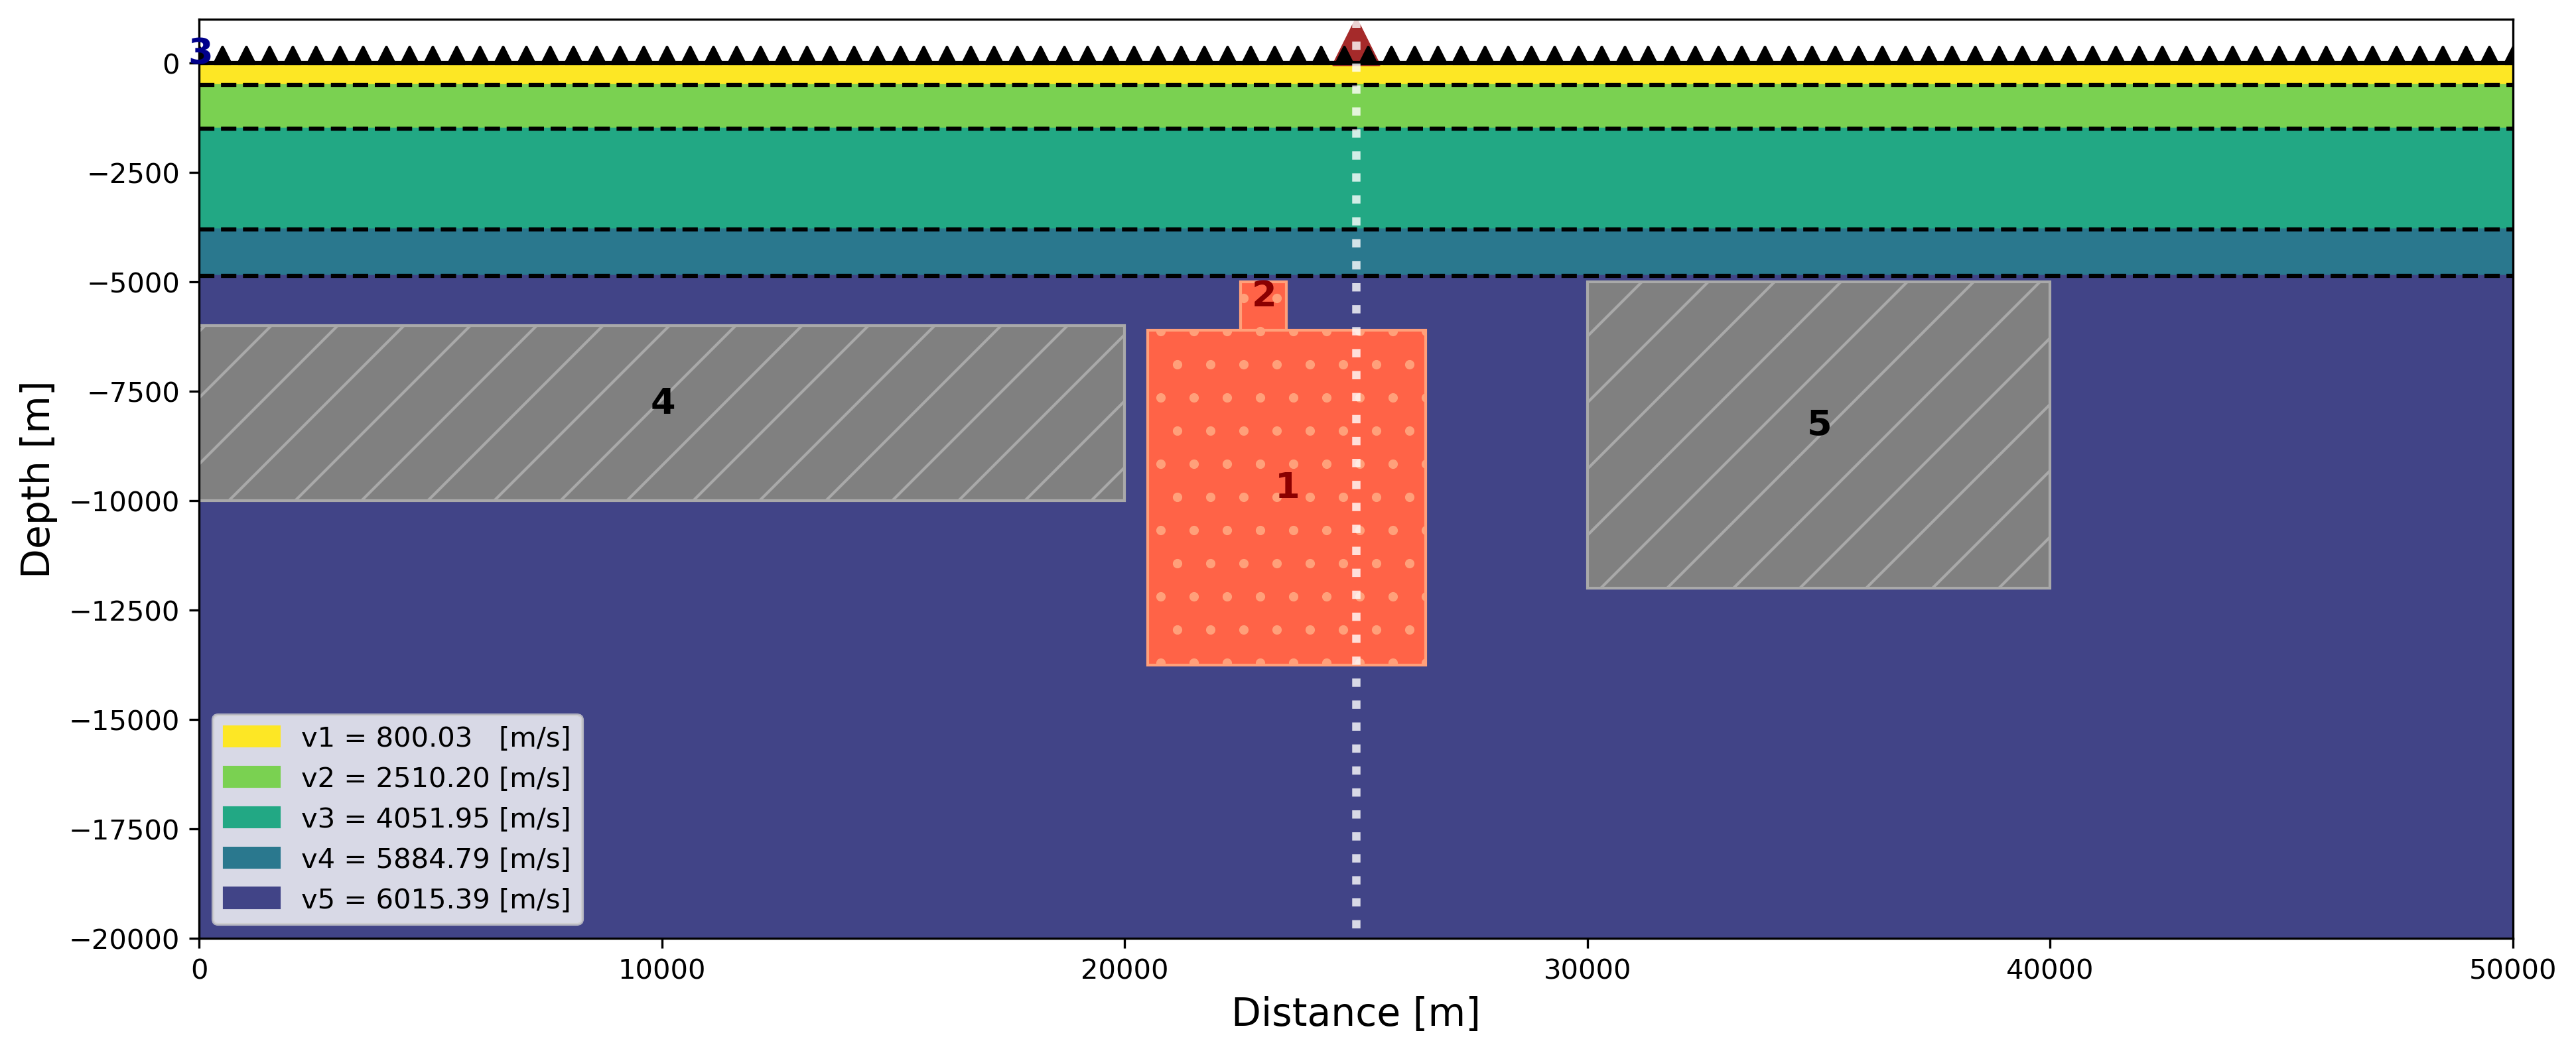

In [99]:
# gravity plot
final_grav_plot = cross_section(int_default,vel_default,magma_grav,hydro_grav,other_grav)

# hydro and other are optional
# deleting hydro_grav from the function call broke the code; so for this plot, it is a tiny square at the top left

Making the plot now...


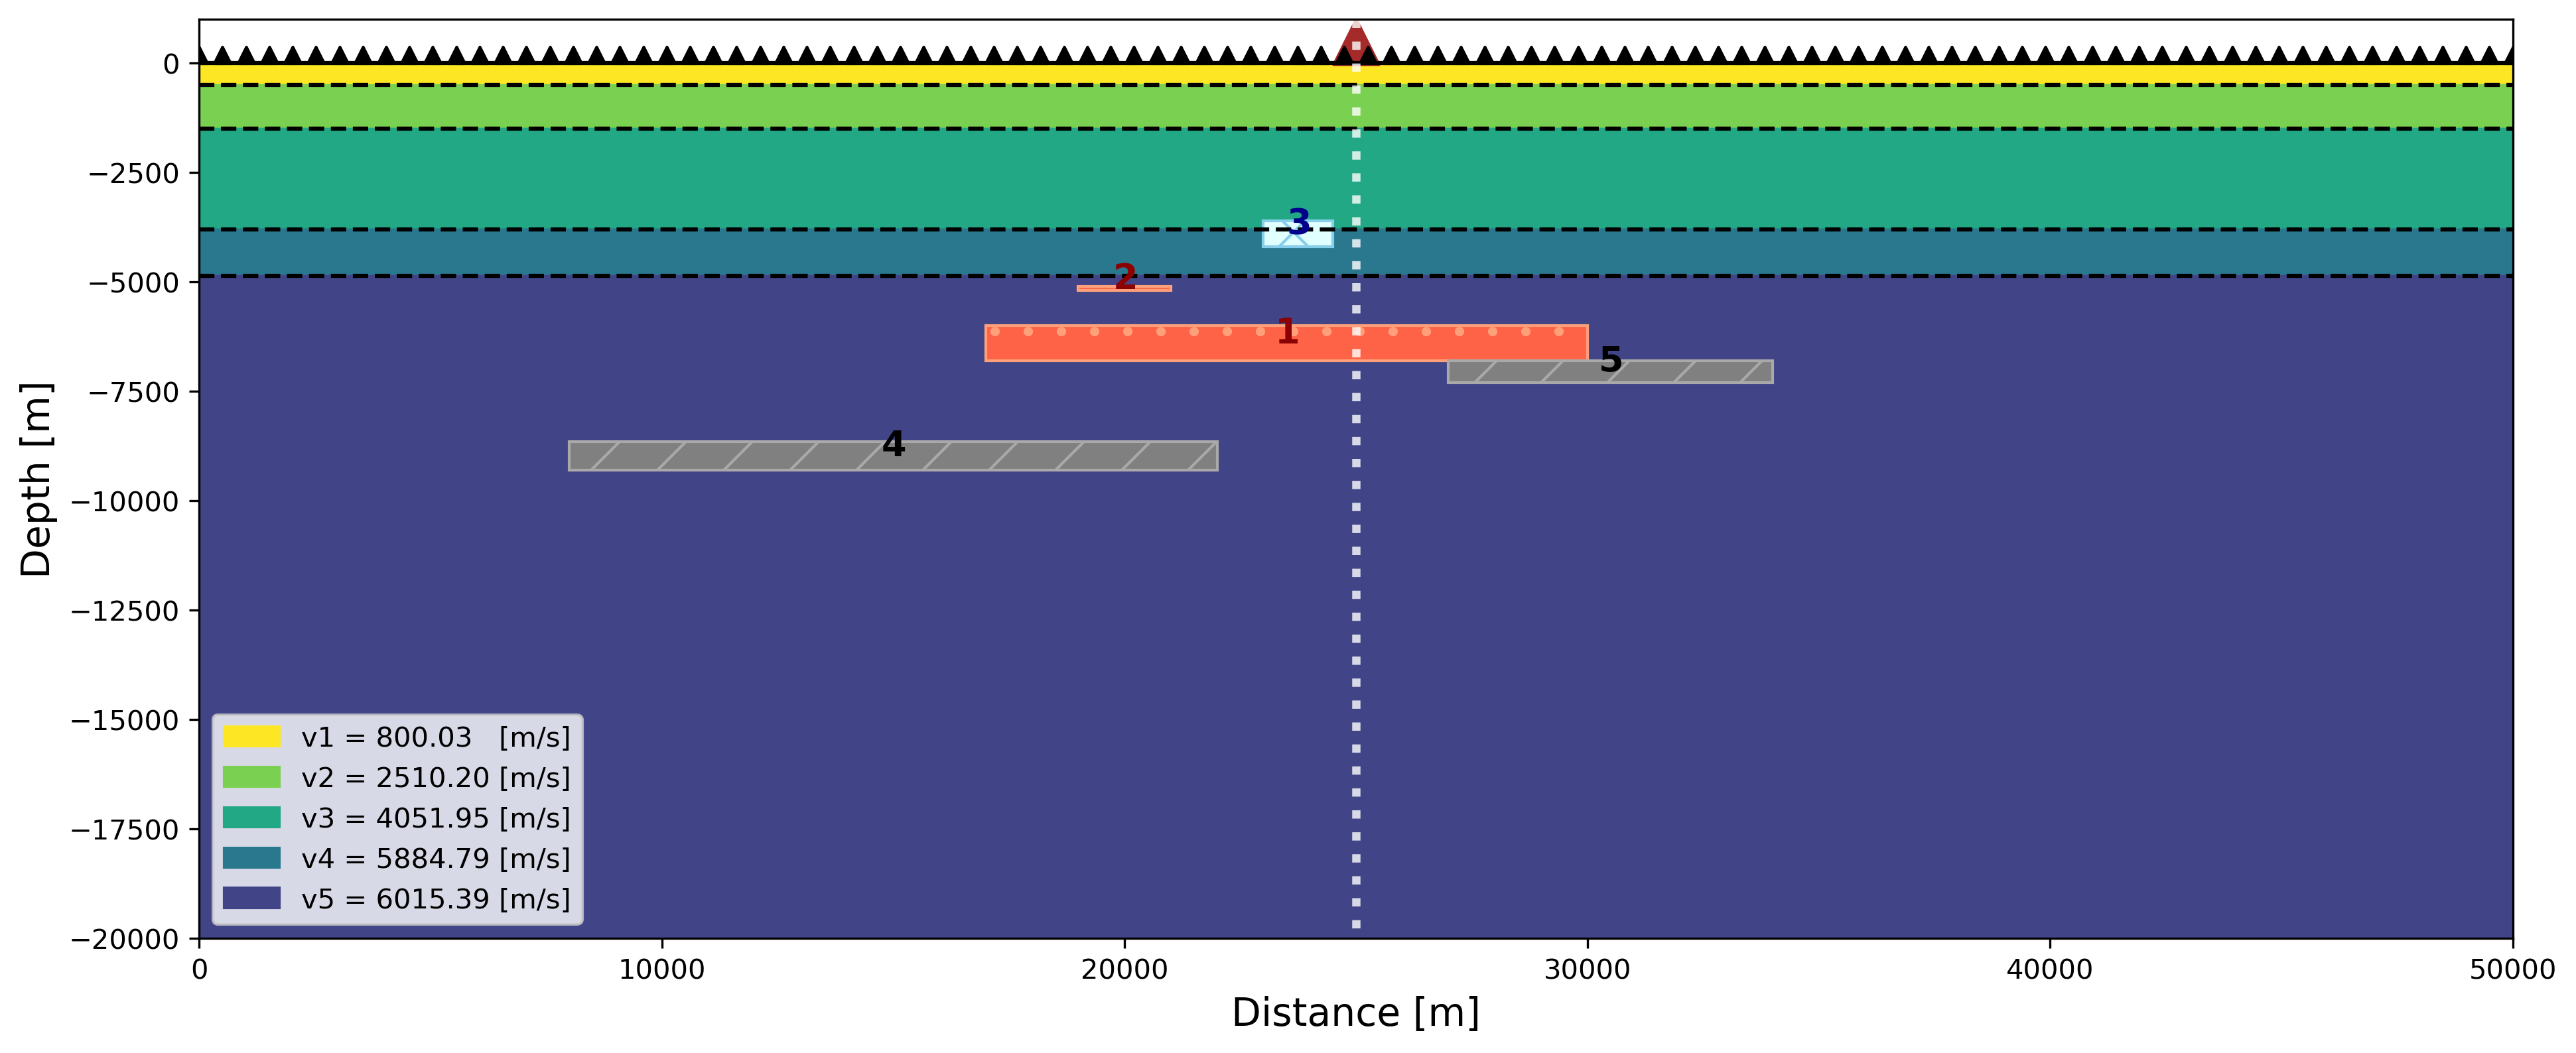

In [101]:
# magnetics plot
final_mag_plot = cross_section(int_default,vel_default,magma_mag,hydro_mag,other_mag)

# hydro and other are optional

As we can see from the data, the first interface head waves appear at 283 meters. This is consistent with the data, which only begins showing refracted head waves at 1050 meters (not 50m, which is before 283m). This implies the first geophone is the only one to detect a direct wave.

The second interface's head waves appear after 2874m, meaning the geophone at 3050 and beyond record refractions from interface 2 instead of interface 1.

Then, the 

---
#### 5.1 Critical Angles

Each refractor will have a critical distance, which is the minimum distance before it appears. Before the first layer's critical distance, the direct wave will be the recorded wave.

\begin{equation}
\tag{5.1.1}
θ_c = \arcsin(\frac{V_n}{V_{n+1}}),
\end{equation}

where $V_n$ is the layer above the interface and $V_{n+1}$ the layer below. This will be different for each interface.

In [ ]:
# calculate critical angles in radians
θ_1_rad = np.arcsin(V_1 / V_2)
θ_2_rad = np.arcsin(V_2 / V_3)
θ_3_rad = np.arcsin(V_3 / V_4)

# convert to degrees for display
θ_1 = np.rad2deg(θ_1_rad)
θ_2 = np.rad2deg(θ_2_rad)
θ_3 = np.rad2deg(θ_3_rad)

print(f'Interface 1 Critical Angle: {θ_1} degrees')
print(f'Interface 2 Critical Angle: {θ_2} degrees')
print(f'Interface 3 Critical Angle: {θ_3} degrees')

In [ ]:
# calculate critical distances
x_crit1 = 2 * h_1 * np.tan(θ_1_rad)
x_crit2 = 2 * h_2 * np.tan(θ_2_rad)
x_crit3 = 2 * h_3 * np.tan(θ_3_rad)

print(f'Critical Distance: {x_crit1} m')
print(f'Critical Distance: {x_crit2} m')
print(f'Critical Distance: {x_crit3} m')

---
#### 3.4 - Reflection Analysis Conclusion

We now have velocities, depths, and thicknesses for every layer and interface. They are laid out here:

| Layer :                     | 1        | 2        | 3        | 4        |
| ----------------------------| -------- | -------- | -------- | -------- |
| Thickness (m)               |504.0795920502921|3462.8223780089334|2960.841396402897|2617.476562151878|
| Lower Interface Depth (m)   |504.0795920502921|3966.9019700592253|6927.743366462122|9545.219928614|
| V_RMS (m/s)                 |800.0320760205128|2379.7544132003195|3593.972458249189|4330.674474439786|
| V_n (m/s)                   |800.0320760205128|2952.233670499331|7700.785988422634|7710.734548976956|
| t_0 (s)                     |1.2601484544411379|3.3338750822816987|3.855201144105031|4.40819091111611|
